LIBRARIES IMPORTATION

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

print("Environment Ready ")

Environment Ready 


LOAD DATASET

In [41]:


customers = pd.read_csv("../data/customers.csv")
delivery_events = pd.read_csv("../data/delivery_events.csv")
driver_metrics = pd.read_csv("../data/driver_monthly_metrics.csv")
drivers = pd.read_csv("../data/drivers.csv")
facilities = pd.read_csv("../data/facilities.csv")
fuel_purchases = pd.read_csv("../data/fuel_purchases.csv")
loads = pd.read_csv("../data/loads.csv")
maintenance = pd.read_csv("../data/maintenance_records.csv")
routes = pd.read_csv("../data/routes.csv")
safety = pd.read_csv("../data/safety_incidents.csv")
trailers = pd.read_csv("../data/trailers.csv")
trips = pd.read_csv("../data/trips.csv")
truck_utilization = pd.read_csv("../data/truck_utilization_metrics.csv")
trucks = pd.read_csv("../data/trucks.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


QUALITY CHECK

In [42]:

datasets = {
    "customers": customers,
    "delivery_events": delivery_events,
    "driver_metrics": driver_metrics,
    "drivers": drivers,
    "facilities": facilities,
    "fuel_purchases": fuel_purchases,
    "loads": loads,
    "maintenance": maintenance,
    "routes": routes,
    "safety": safety,
    "trailers": trailers,
    "trips": trips,
    "truck_utilization": truck_utilization,
    "trucks": trucks
}

for name, df in datasets.items():
    print("=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\n")

CUSTOMERS
Shape: (200, 8)

Columns:
['customer_id', 'customer_name', 'customer_type', 'credit_terms_days', 'primary_freight_type', 'account_status', 'contract_start_date', 'annual_revenue_potential']

Missing Values:
customer_id                 0
customer_name               0
customer_type               0
credit_terms_days           0
primary_freight_type        0
account_status              0
contract_start_date         0
annual_revenue_potential    0
dtype: int64


DELIVERY_EVENTS
Shape: (170820, 11)

Columns:
['event_id', 'load_id', 'trip_id', 'event_type', 'facility_id', 'scheduled_datetime', 'actual_datetime', 'detention_minutes', 'on_time_flag', 'location_city', 'location_state']

Missing Values:
event_id              0
load_id               0
trip_id               0
event_type            0
facility_id           0
scheduled_datetime    0
actual_datetime       0
detention_minutes     0
on_time_flag          0
location_city         0
location_state        0
dtype: int64


DRIVER_ME

DATA SET SUMMARY

In [43]:

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum()
    })

summary_df = pd.DataFrame(summary)

summary_df.sort_values(by="Rows", ascending=False)

,Dataset,Rows,Columns,Missing Values
5,fuel_purchases,196442,11,7868
1,delivery_events,170820,11,0
11,trips,85410,12,5066
6,loads,85410,12,0
2,driver_metrics,4464,9,0
12,truck_utilization,3312,10,0
7,maintenance,2920,12,0
0,customers,200,8,0
10,trailers,180,9,0
9,safety,170,15,2


DATA SET DESCRIPTION

In [44]:

#LOADS
loads.head()
loads.info()

<class 'pandas.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   load_id              85410 non-null  str    
 1   customer_id          85410 non-null  str    
 2   route_id             85410 non-null  str    
 3   load_date            85410 non-null  str    
 4   load_type            85410 non-null  str    
 5   weight_lbs           85410 non-null  int64  
 6   pieces               85410 non-null  int64  
 7   revenue              85410 non-null  float64
 8   fuel_surcharge       85410 non-null  float64
 9   accessorial_charges  85410 non-null  int64  
 10  load_status          85410 non-null  str    
 11  booking_type         85410 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 7.8 MB


In [45]:
#TRIPS
trips.head()
trips.info()

<class 'pandas.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_id                85410 non-null  str    
 1   load_id                85410 non-null  str    
 2   driver_id              83696 non-null  str    
 3   truck_id               83738 non-null  str    
 4   trailer_id             83730 non-null  str    
 5   dispatch_date          85410 non-null  str    
 6   actual_distance_miles  85410 non-null  int64  
 7   actual_duration_hours  85410 non-null  float64
 8   fuel_gallons_used      85410 non-null  float64
 9   average_mpg            85410 non-null  float64
 10  idle_time_hours        85410 non-null  float64
 11  trip_status            85410 non-null  str    
dtypes: float64(4), int64(1), str(7)
memory usage: 7.8 MB


In [46]:
#DELIVERY EVENTS
delivery_events.head()
delivery_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 170820 entries, 0 to 170819
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   event_id            170820 non-null  str  
 1   load_id             170820 non-null  str  
 2   trip_id             170820 non-null  str  
 3   event_type          170820 non-null  str  
 4   facility_id         170820 non-null  str  
 5   scheduled_datetime  170820 non-null  str  
 6   actual_datetime     170820 non-null  str  
 7   detention_minutes   170820 non-null  int64
 8   on_time_flag        170820 non-null  bool 
 9   location_city       170820 non-null  str  
 10  location_state      170820 non-null  str  
dtypes: bool(1), int64(1), str(9)
memory usage: 13.2 MB


In [47]:
#FUEL PURCHASES
fuel_purchases.head()
fuel_purchases.info()


<class 'pandas.DataFrame'>
RangeIndex: 196442 entries, 0 to 196441
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   fuel_purchase_id  196442 non-null  str    
 1   trip_id           196442 non-null  str    
 2   truck_id          192562 non-null  str    
 3   driver_id         192454 non-null  str    
 4   purchase_date     196442 non-null  str    
 5   location_city     196442 non-null  str    
 6   location_state    196442 non-null  str    
 7   gallons           196442 non-null  float64
 8   price_per_gallon  196442 non-null  float64
 9   total_cost        196442 non-null  float64
 10  fuel_card_number  196442 non-null  str    
dtypes: float64(3), str(8)
memory usage: 16.5 MB


In [48]:
#MAINTENANCE
maintenance.head()
maintenance.info()

<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   maintenance_id       2920 non-null   str    
 1   truck_id             2920 non-null   str    
 2   maintenance_date     2920 non-null   str    
 3   maintenance_type     2920 non-null   str    
 4   odometer_reading     2920 non-null   int64  
 5   labor_hours          2920 non-null   float64
 6   labor_cost           2920 non-null   float64
 7   parts_cost           2920 non-null   float64
 8   total_cost           2920 non-null   float64
 9   facility_location    2920 non-null   str    
 10  downtime_hours       2920 non-null   float64
 11  service_description  2920 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 273.9 KB


In [49]:
#CONVERT DATES COLUMNS

loads['load_date'] = pd.to_datetime(loads['load_date'])

trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'])

delivery_events['scheduled_datetime'] = pd.to_datetime(delivery_events['scheduled_datetime'])
delivery_events['actual_datetime'] = pd.to_datetime(delivery_events['actual_datetime'])

fuel_purchases['purchase_date'] = pd.to_datetime(fuel_purchases['purchase_date'])

maintenance['maintenance_date'] = pd.to_datetime(maintenance['maintenance_date'])

print("Date conversion completed")

Date conversion completed


In [50]:
#CREATING TIME FEATURES
# Loads time features

loads['year'] = loads['load_date'].dt.year
loads['month'] = loads['load_date'].dt.month
loads['month_name'] = loads['load_date'].dt.month_name()

# Trips time features

trips['year'] = trips['dispatch_date'].dt.year
trips['month'] = trips['dispatch_date'].dt.month
trips['month_name'] = trips['dispatch_date'].dt.month_name()

print("Time features created")

Time features created


In [51]:
#CORE KPI
total_revenue = loads['revenue'].sum()

total_loads = loads['load_id'].nunique()

total_trips = trips['trip_id'].nunique()

total_distance = trips['actual_distance_miles'].sum()

avg_mpg = trips['average_mpg'].mean()

on_time_rate = delivery_events['on_time_flag'].mean() * 100

total_fuel_cost = fuel_purchases['total_cost'].sum()

total_maintenance_cost = maintenance['total_cost'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Loads: {total_loads:,}")
print(f"Total Trips: {total_trips:,}")
print(f"Total Distance: {total_distance:,} miles")
print(f"Average MPG: {avg_mpg:.2f}")
print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")
print(f"Total Fuel Cost: ${total_fuel_cost:,.2f}")
print(f"Total Maintenance Cost: ${total_maintenance_cost:,.2f}")

Total Revenue: $262,525,800.29
Total Loads: 85,410
Total Trips: 85,410
Total Distance: 122,159,201 miles
Average MPG: 6.50
On-Time Delivery Rate: 55.67%
Total Fuel Cost: $95,592,992.04
Total Maintenance Cost: $5,730,573.28


#REVENUE ANALYSIS

In [52]:

#Revenue by Load
revenue_by_load = loads.groupby('load_type')['revenue'].sum().sort_values(ascending=False)

revenue_by_load

load_type
Refrigerated    1.319670e+08
Dry Van         1.305588e+08
Name: revenue, dtype: float64

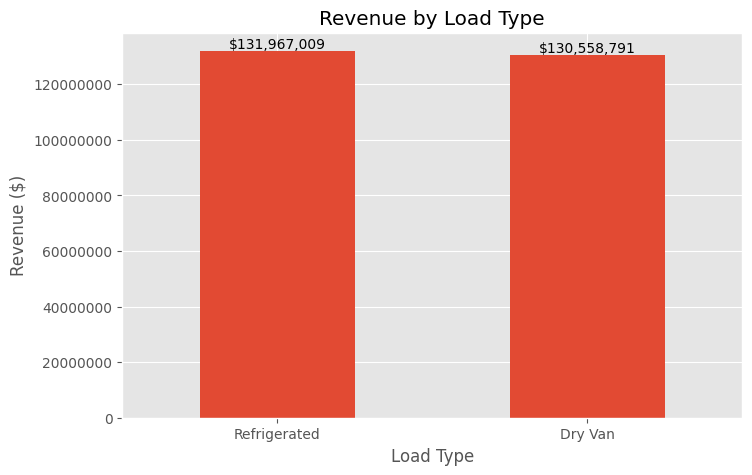

In [53]:
plt.figure(figsize=(8,5))

ax = revenue_by_load.plot(kind='bar')

for i, value in enumerate(revenue_by_load):
    ax.text(i, value + 1000000, f'${value:,.0f}', ha='center')

plt.title('Revenue by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)

plt.ticklabel_format(style='plain', axis='y')

plt.show()

In [54]:
#Revenue by booking
booking_revenue = loads.groupby('booking_type')['revenue'].sum().sort_values(ascending=False)

booking_revenue

booking_type
Dedicated    1.302366e+08
Spot         6.632171e+07
Contract     6.596746e+07
Name: revenue, dtype: float64

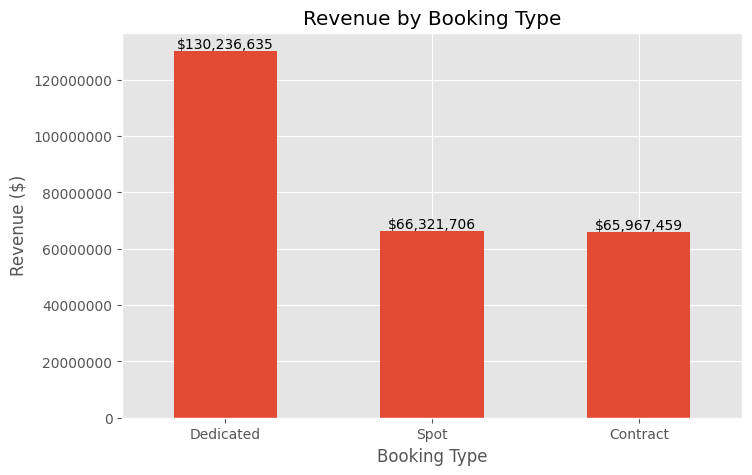

In [55]:
plt.figure(figsize=(8,5))

ax = booking_revenue.plot(kind='bar')


for i, value in enumerate(booking_revenue):
    ax.text(i, value + 1000000, f'${value:,.0f}', ha='center')


plt.title('Revenue by Booking Type')
plt.xlabel('Booking Type')
plt.ylabel('Revenue ($)')

plt.xticks(rotation=0)

plt.ticklabel_format(style='plain', axis='y')

plt.show()

In [56]:
#MONTHLY TREND
monthly_revenue = loads.groupby('month_name')['revenue'].sum()

monthly_revenue

month_name
April        21568821.09
August       22260927.64
December     21825972.27
February     20163263.00
January      22380644.35
July         22267253.36
June         22093111.17
March        22364541.75
May          22331443.50
November     21591465.76
October      22405461.00
September    21272895.40
Name: revenue, dtype: float64

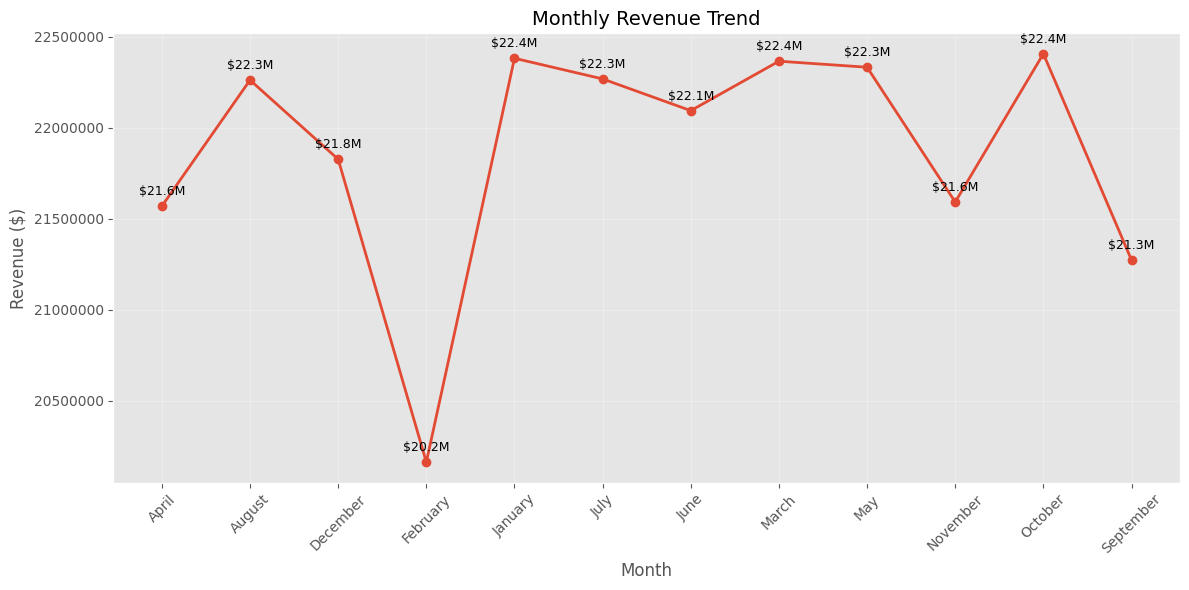

In [57]:
plt.figure(figsize=(12,6))

ax = monthly_revenue.plot(
    marker='o',
    linewidth=2
)

# Add value labels
for i, value in enumerate(monthly_revenue):
    ax.annotate(
        f'${value/1e6:.1f}M',
        (i, value),
        textcoords="offset points",
        xytext=(0,8),
        ha='center',
        fontsize=9
    )

# Force all months to display
ax.set_xticks(range(len(monthly_revenue.index)))
ax.set_xticklabels(monthly_revenue.index, rotation=45)

# Formatting
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')

plt.ticklabel_format(style='plain', axis='y')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

Trip & Fleet Performance Analysis

In [58]:
#Average MPG
avg_mpg = trips['average_mpg'].mean()

print(f"Average Fleet MPG: {avg_mpg:.2f}")

Average Fleet MPG: 6.50


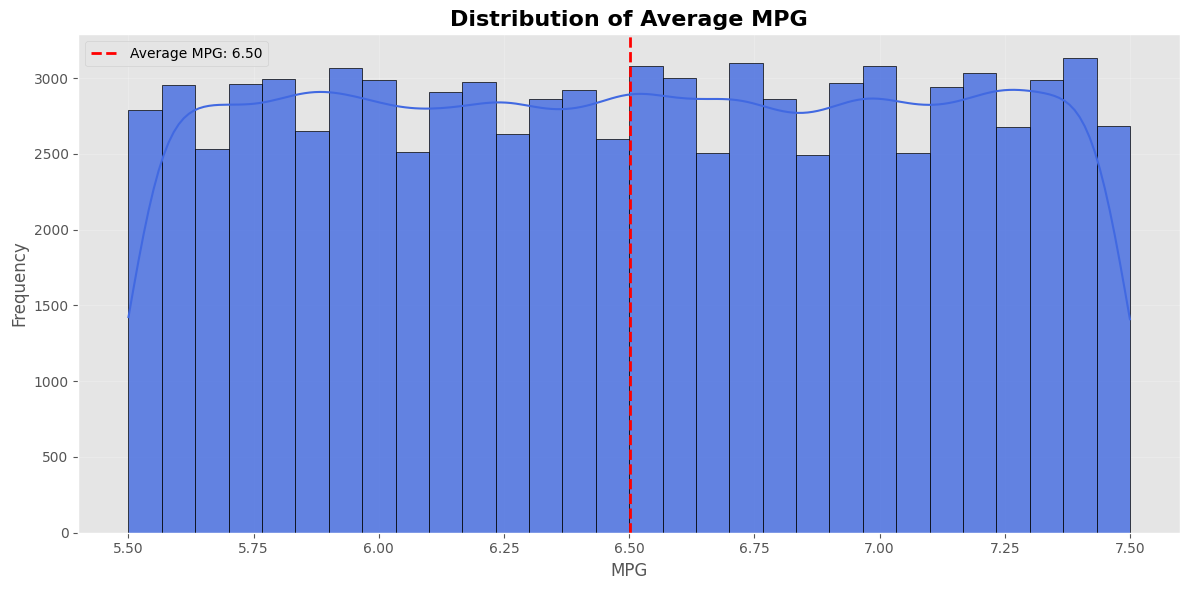

In [63]:
plt.figure(figsize=(12,6))

# Histogram with KDE
sns.histplot(
    trips['average_mpg'],
    bins=30,
    kde=True,
    color='royalblue',
    edgecolor='black',
    alpha=0.8
)

# Average MPG line
plt.axvline(
    avg_mpg,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Average MPG: {avg_mpg:.2f}'
)

# Titles and labels
plt.title('Distribution of Average MPG', fontsize=16, fontweight='bold')
plt.xlabel('MPG', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Legend
plt.legend()

# Grid styling
plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

In [64]:
#IDLE TIME ANALYSIS
avg_idle = trips['idle_time_hours'].mean()

print(f"Average Idle Time: {avg_idle:.2f} hours")

Average Idle Time: 7.01 hours


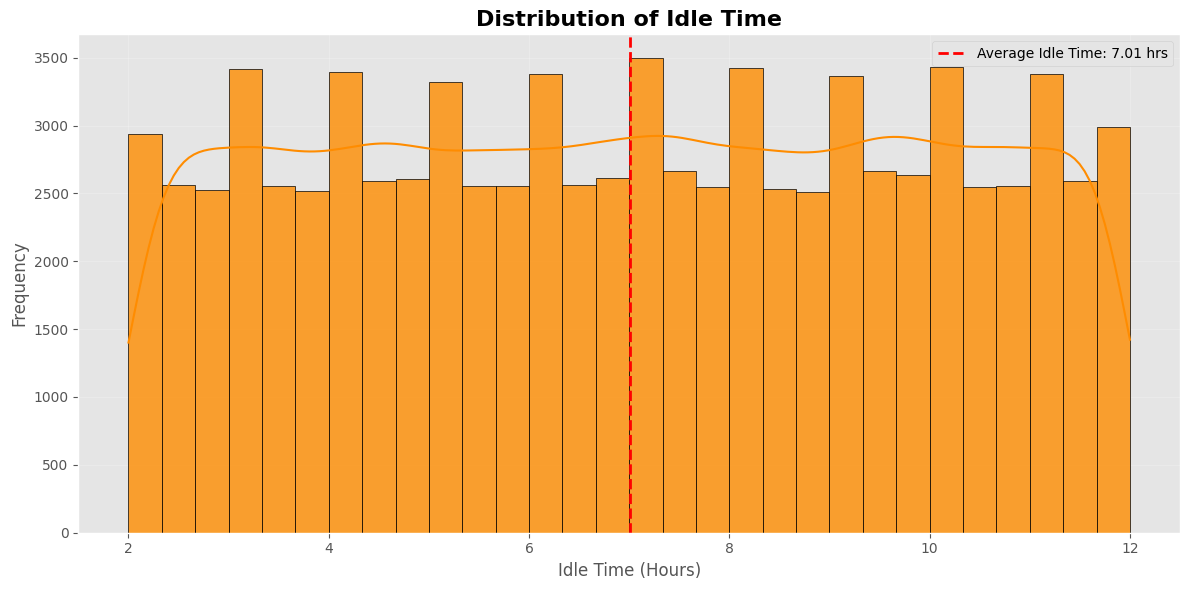

In [66]:
# Average Idle Time
avg_idle = trips['idle_time_hours'].mean()

plt.figure(figsize=(12,6))

# Histogram with KDE
sns.histplot(
    trips['idle_time_hours'],
    bins=30,
    kde=True,
    color='darkorange',
    edgecolor='black',
    alpha=0.8
)

# Average Idle Time line
plt.axvline(
    avg_idle,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Average Idle Time: {avg_idle:.2f} hrs'
)

# Titles and labels
plt.title('Distribution of Idle Time', fontsize=16, fontweight='bold')
plt.xlabel('Idle Time (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Legend
plt.legend()

# Grid styling
plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

TRIP DISTANCE 

In [67]:
#Averae Distance
avg_distance = trips['actual_distance_miles'].mean()

print(f"Average Trip Distance: {avg_distance:,.2f} miles")

Average Trip Distance: 1,430.27 miles


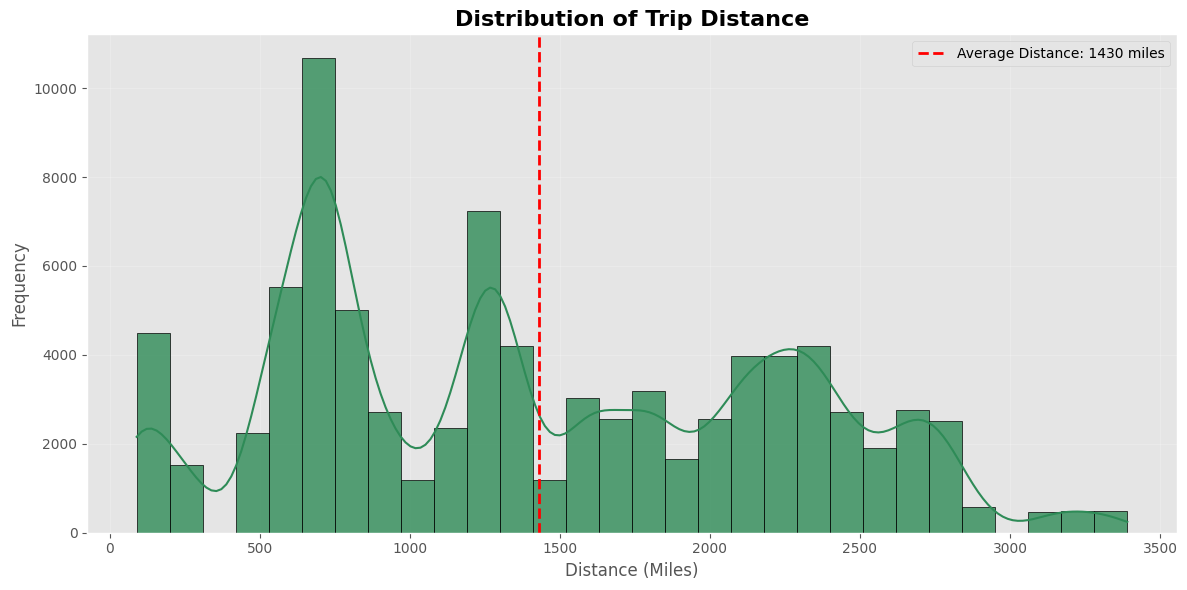

In [69]:
# Average Distance
avg_distance = trips['actual_distance_miles'].mean()

plt.figure(figsize=(12,6))

# Histogram with KDE
sns.histplot(
    trips['actual_distance_miles'],
    bins=30,
    kde=True,
    color='seagreen',
    edgecolor='black',
    alpha=0.8
)

# Average distance line
plt.axvline(
    avg_distance,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Average Distance: {avg_distance:.0f} miles'
)

# Titles and labels
plt.title('Distribution of Trip Distance', fontsize=16, fontweight='bold')
plt.xlabel('Distance (Miles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Legend
plt.legend()

# Grid styling
plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

In [70]:
#AVERAGE DURATION
avg_duration = trips['actual_duration_hours'].mean()

print(f"Average Trip Duration: {avg_duration:.2f} hours")

Average Trip Duration: 25.01 hours


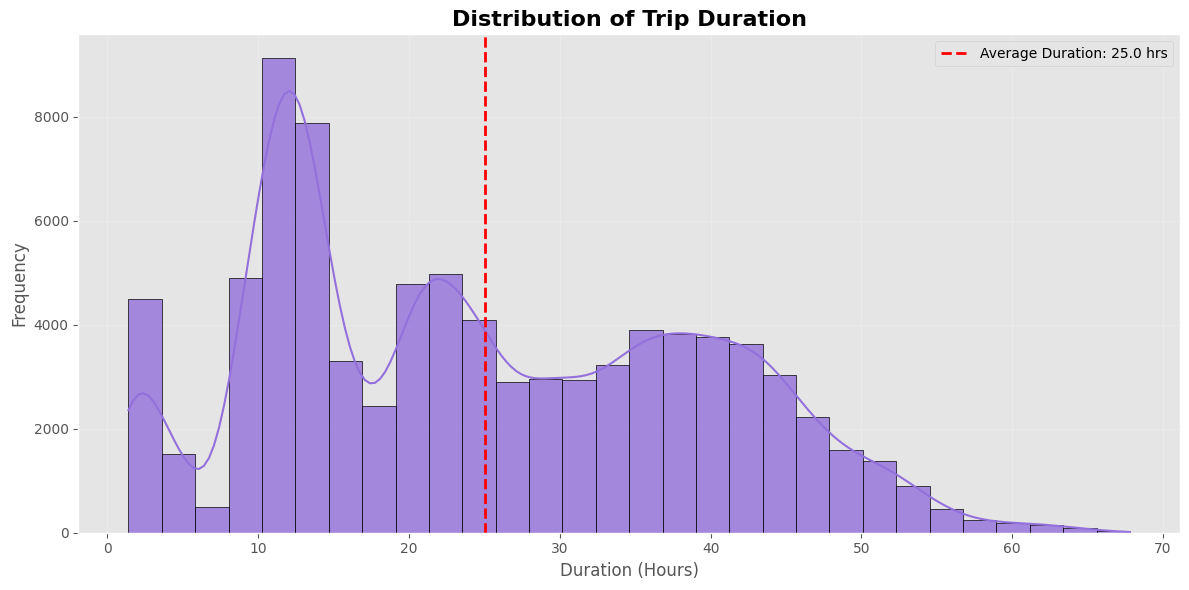

In [72]:
# Average Trip Duration
avg_duration = trips['actual_duration_hours'].mean()

plt.figure(figsize=(12,6))

# Histogram with KDE
sns.histplot(
    trips['actual_duration_hours'],
    bins=30,
    kde=True,
    color='mediumpurple',
    edgecolor='black',
    alpha=0.8
)

# Average duration line
plt.axvline(
    avg_duration,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Average Duration: {avg_duration:.1f} hrs'
)

# Titles and labels
plt.title('Distribution of Trip Duration', fontsize=16, fontweight='bold')
plt.xlabel('Duration (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Legend
plt.legend()

# Grid styling
plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()


DELIVERY PERFORMANCE

In [74]:
on_time_rate = delivery_events['on_time_flag'].mean() * 100

print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")

#ONTIME VS LATE
delivery_status = delivery_events['on_time_flag'].value_counts()

delivery_status

On-Time Delivery Rate: 55.67%


on_time_flag
True     95095
False    75725
Name: count, dtype: int64

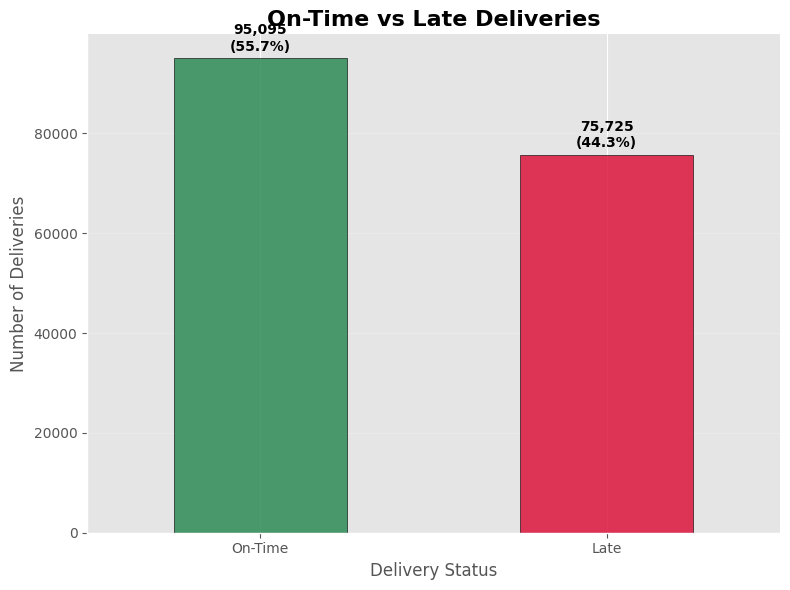

In [81]:
# Count delivery status
delivery_status = delivery_events['on_time_flag'].value_counts()

# Rename labels
delivery_status.index = ['On-Time', 'Late']

# Calculate percentages
percentages = (delivery_status / delivery_status.sum()) * 100

# Create figure
plt.figure(figsize=(8,6))

# Custom colors
colors = ['seagreen', 'crimson']

# Plot bars
ax = delivery_status.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    alpha=0.85
)

# Add labels and percentages
for i, value in enumerate(delivery_status):
    ax.text(
        i,
        value + 1500,
        f'{value:,}\n({percentages.iloc[i]:.1f}%)',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Titles and labels
plt.title('On-Time vs Late Deliveries', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Number of Deliveries', fontsize=12)

# Rotate labels
plt.xticks(rotation=0)

# Light grid
plt.grid(axis='y', alpha=0.2)

# Remove top/right spines
sns.despine()

plt.tight_layout()

plt.show()

In [82]:
#Average detention
avg_detention = delivery_events['detention_minutes'].mean()

print(f"Average Detention Time: {avg_detention:.2f} minutes")

Average Detention Time: 91.54 minutes


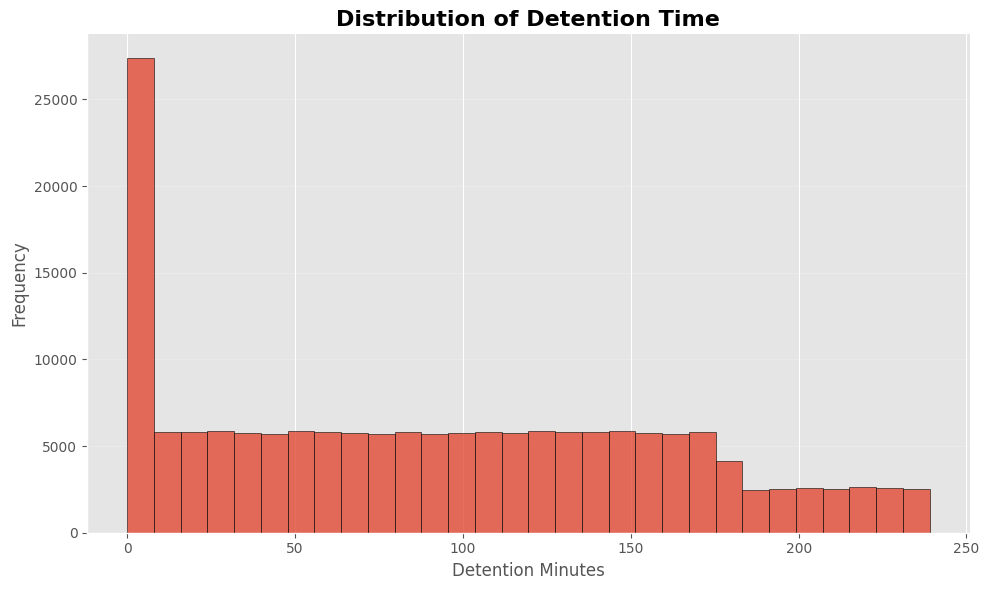

In [83]:
plt.figure(figsize=(10,6))

plt.hist(
    delivery_events['detention_minutes'],
    bins=30,
    edgecolor='black',
    alpha=0.8
)

plt.title('Distribution of Detention Time', fontsize=16, fontweight='bold')
plt.xlabel('Detention Minutes', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

In [84]:
#Average Deteention by State
state_detention = delivery_events.groupby('location_state')['detention_minutes'].mean().sort_values(ascending=False)

state_detention.head(10)

location_state
IN    106.226334
CA    105.321971
CO     98.802660
MI     96.409442
OR     95.695235
NY     95.067602
WA     94.758923
MN     91.949983
GA     91.770085
TN     91.519127
Name: detention_minutes, dtype: float64

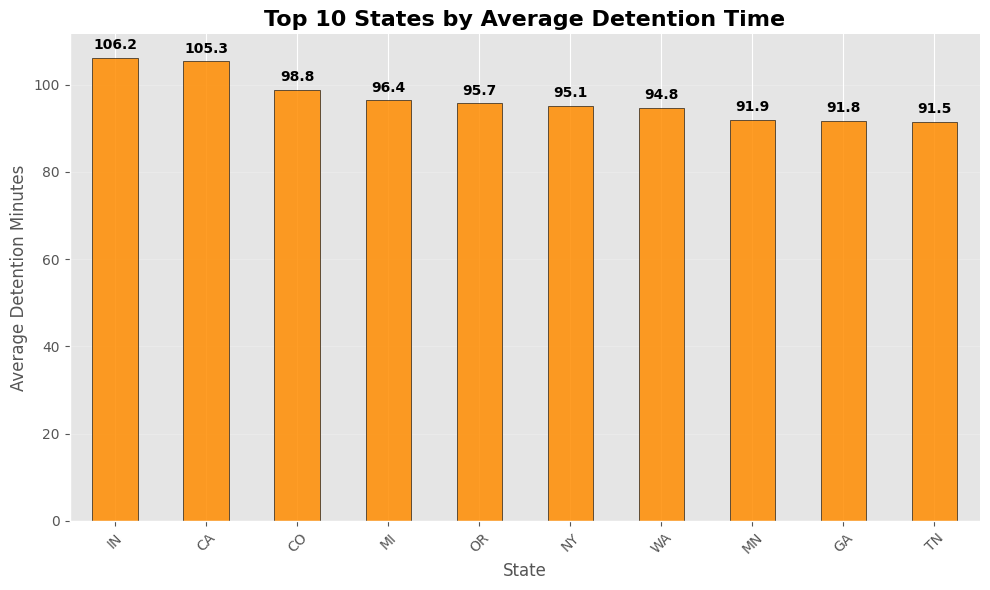

In [85]:
top_states = state_detention.head(10)

plt.figure(figsize=(10,6))

ax = top_states.plot(
    kind='bar',
    color='darkorange',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(top_states):
    ax.text(
        i,
        value + 2,
        f'{value:.1f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Top 10 States by Average Detention Time', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Detention Minutes', fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

FUEL COST KPI

In [86]:
#FUEL COST KPI
total_fuel_cost = fuel_purchases['total_cost'].sum()

print(f"Total Fuel Cost: ${total_fuel_cost:,.2f}")

Total Fuel Cost: $95,592,992.04


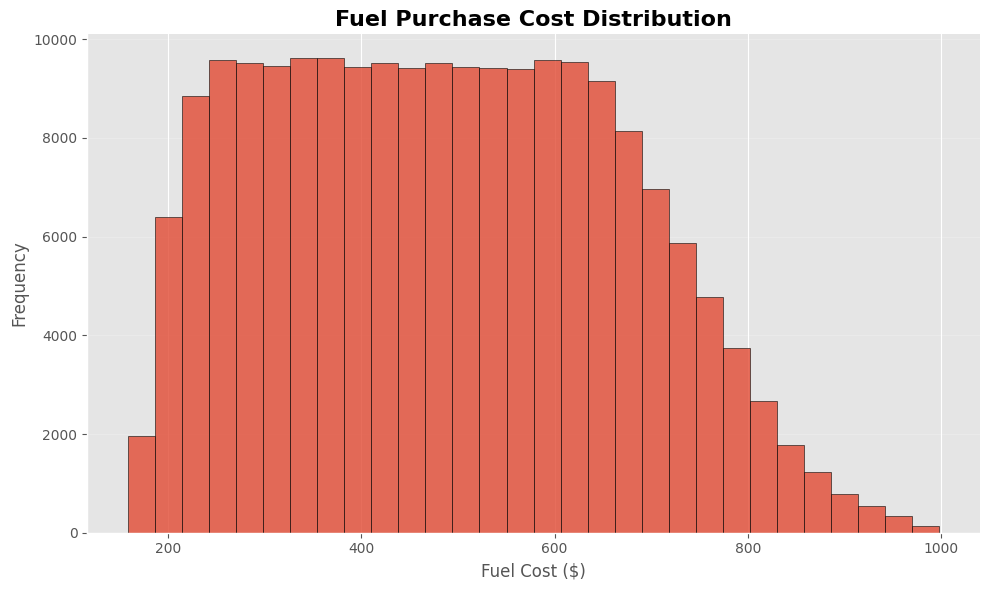

In [87]:
#Fuel Cost Distribution
plt.figure(figsize=(10,6))

plt.hist(
    fuel_purchases['total_cost'],
    bins=30,
    edgecolor='black',
    alpha=0.8
)

plt.title('Fuel Purchase Cost Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Fuel Cost ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

In [88]:
#MAINTENANCE COST
total_maintenance_cost = maintenance['total_cost'].sum()

print(f"Total Maintenance Cost: ${total_maintenance_cost:,.2f}")

Total Maintenance Cost: $5,730,573.28


In [89]:
#MAINTENANCE COST BY TYPE
maintenance_by_type = maintenance.groupby('maintenance_type')['total_cost'].sum().sort_values(ascending=False)

maintenance_by_type

maintenance_type
Preventive      963576.34
Repair          945375.44
Tire            919413.24
Brake           911667.23
Engine          890537.88
Transmission    879620.87
Inspection      220382.28
Name: total_cost, dtype: float64

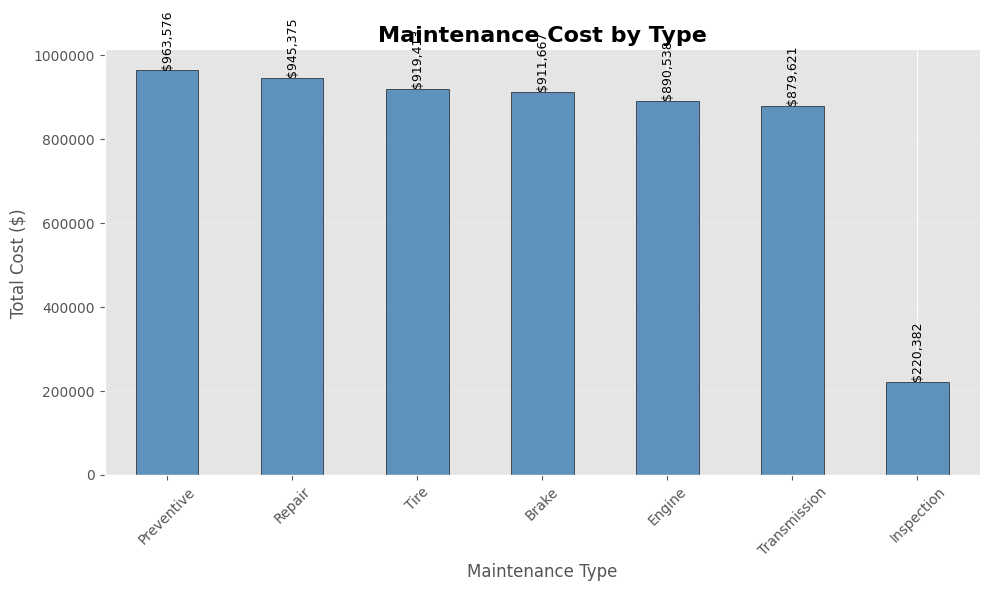

In [90]:
plt.figure(figsize=(10,6))

ax = maintenance_by_type.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(maintenance_by_type):
    ax.text(
        i,
        value + 10000,
        f'${value:,.0f}',
        ha='center',
        fontsize=9,
        rotation=90
    )

plt.title('Maintenance Cost by Type', fontsize=16, fontweight='bold')
plt.xlabel('Maintenance Type', fontsize=12)
plt.ylabel('Total Cost ($)', fontsize=12)

plt.xticks(rotation=45)

plt.ticklabel_format(style='plain', axis='y')

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

DOWNTIME ANALYSIS

In [91]:
avg_downtime = maintenance['downtime_hours'].mean()

print(f"Average Downtime: {avg_downtime:.2f} hours")

Average Downtime: 24.74 hours


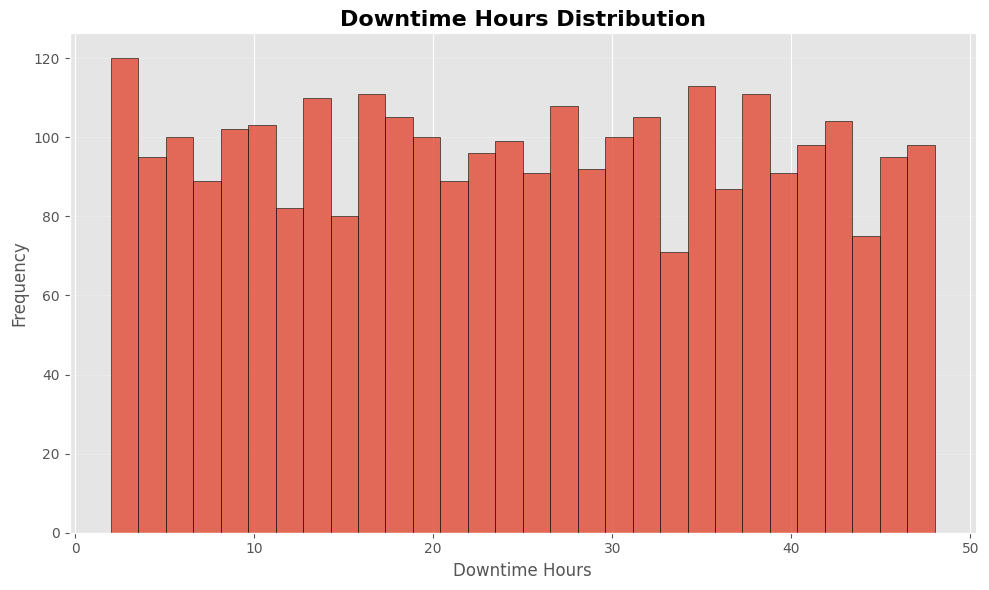

In [92]:
plt.figure(figsize=(10,6))

plt.hist(
    maintenance['downtime_hours'],
    bins=30,
    edgecolor='black',
    alpha=0.8
)

plt.title('Downtime Hours Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Downtime Hours', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

In [93]:
#FUEL COST BY STATE
fuel_by_state = fuel_purchases.groupby('location_state')['total_cost'].sum().sort_values(ascending=False)

fuel_by_state.head(10)

location_state
TX    7640445.07
TN    7616750.66
MI    3951520.98
IN    3878326.22
MO    3861647.51
OK    3857532.22
WI    3847379.31
OH    3845962.10
NC    3843962.67
FL    3841320.28
Name: total_cost, dtype: float64

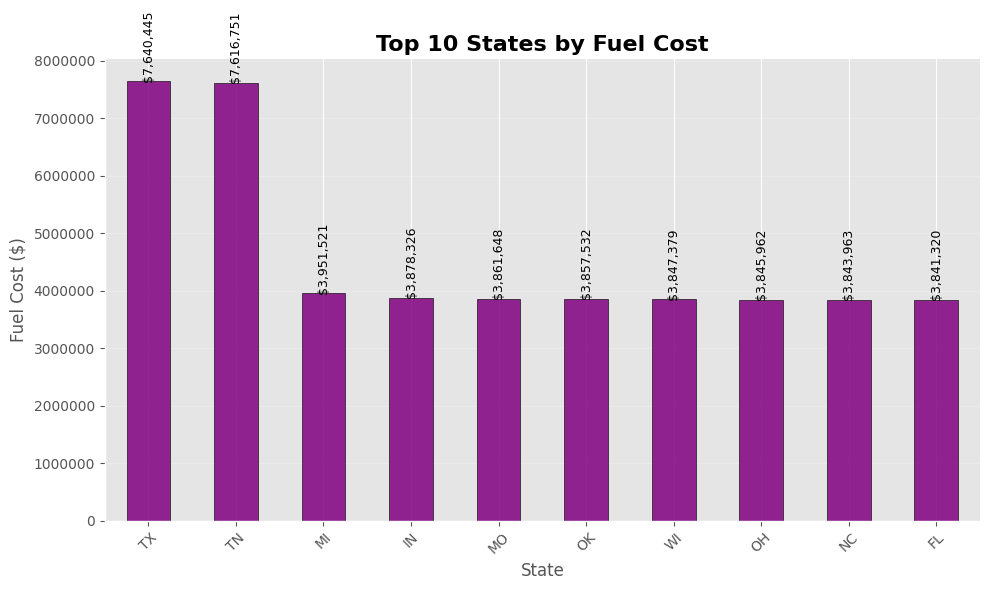

In [94]:
top_fuel_states = fuel_by_state.head(10)

plt.figure(figsize=(10,6))

ax = top_fuel_states.plot(
    kind='bar',
    color='purple',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(top_fuel_states):
    ax.text(
        i,
        value + 50000,
        f'${value:,.0f}',
        ha='center',
        fontsize=9,
        rotation=90
    )

plt.title('Top 10 States by Fuel Cost', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Fuel Cost ($)', fontsize=12)

plt.xticks(rotation=45)

plt.ticklabel_format(style='plain', axis='y')

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

TOP REVENUE CUSTOMERS

In [95]:
customer_revenue = loads.groupby('customer_id')['revenue'].sum().sort_values(ascending=False)

customer_revenue.head(10)

customer_id
CUST00200    1544419.81
CUST00181    1542321.02
CUST00077    1521982.07
CUST00097    1487129.31
CUST00122    1483188.90
CUST00028    1481527.84
CUST00110    1479584.73
CUST00101    1477854.32
CUST00124    1472131.31
CUST00196    1471132.90
Name: revenue, dtype: float64

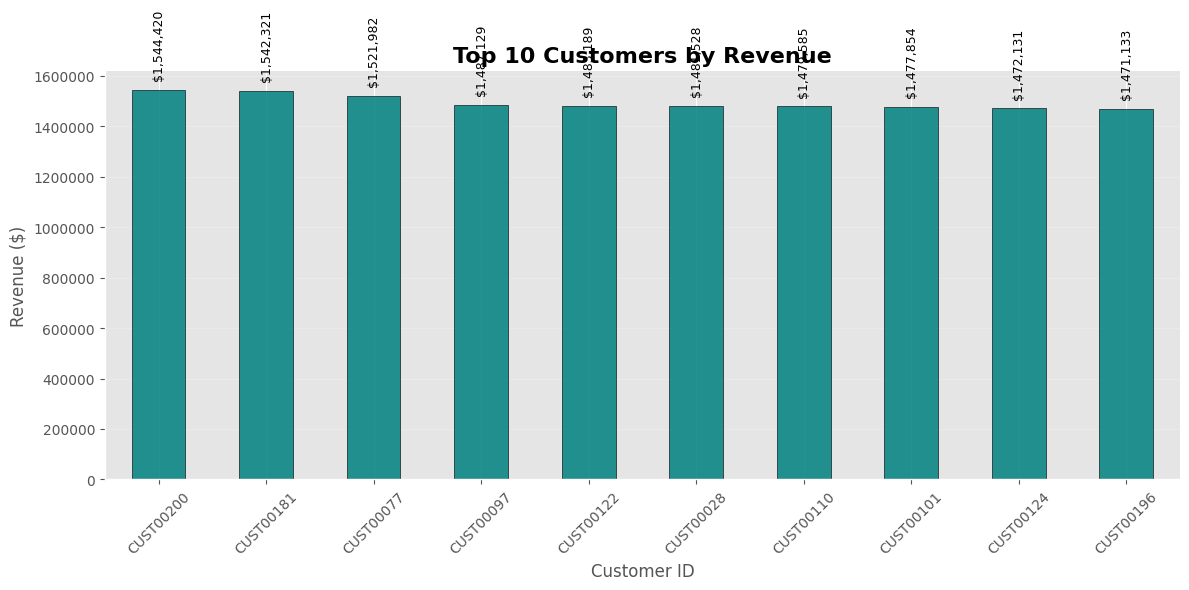

In [96]:
top_customers = customer_revenue.head(10)

plt.figure(figsize=(12,6))

ax = top_customers.plot(
    kind='bar',
    color='teal',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(top_customers):
    ax.text(
        i,
        value + 50000,
        f'${value:,.0f}',
        ha='center',
        fontsize=9,
        rotation=90
    )

plt.title('Top 10 Customers by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

plt.xticks(rotation=45)

plt.ticklabel_format(style='plain', axis='y')

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()